## <span style="color:blue"> Lezione 3 </span>


In [1]:
from scipy.special import erf
import numpy as np
from numpy import exp
from numpy.lib.scimath import log, sqrt
import matplotlib.pyplot as plt


### Processo di Wiener (Moto browniano standard )

Un processo di Wiener è un processo stocastico per cui: 

1. $W(0) = 0$.
2. Gli incrementi $W(t) - W(s)$ sono stazionari e indipendenti.
3. Per $t>s$, $W(t) - W(s)$ sono distribuiti secondo una gaussiana centrata in $0$ e con varianza $t-s$.


L'ultima condizione implica che $W(t)$ è distribuito secondo una gaussiana centrata in $0$ e con varianza $t$, e $$ W(t_{i+1})=W(t_i)  + Z_{i+1}\sqrt{t_{i+1}-t_i} $$ 
con $Z_i \sim \mathcal{N}(0,1)$.
### Moto browniano non standard


Un processo stocastico $X(t)$ è detto moto browniano (non standard) se $\left(X(t) - \mu t\right) / \sigma $ è un processo di Wiener. 

Soddisfa l'equazione stocastica di Ito: $$ \mathrm{d}X(t)=\mu \mathrm{d}t + \sigma \mathrm{d} W(t).$$ $X(t)$ è distribuito secondo una gaussiana con valore medio $\mu t$ e varianza $\sigma^2 t$. 

### Moto browniano geometrico 


Un processo stocastico $S(t)$ è un moto browniano geometrico se soddisfa la seguente equazione di Ito: $$\mathrm{d}S(t)= \mu S(t) \mathrm{d} t + \sigma S(t) \mathrm{d} W(t),$$ 
con $W(t)$ processo di Wiener. $\mu$  è detto _drift_ e $\sigma$ _volatility_. Dalla formula di Ito, si ottiene $$\mathrm{d}\log S(t)= \left( \mu - \frac{1}{2}\sigma^2\right) \mathrm{d} t + \sigma \mathrm{d} W(t),$$
che è l'equazione di un moto browniano non standard.   

Per cui : $$ \log S(t_{i+1})= \log S(t_i)  +  \left(\mu-\frac{1}{2}\sigma^2\right)(t_{i+1}-t_i) +\sigma Z_{i+1}\sqrt{t_{i+1}-t_i} , $$ con $Z_i \sim \mathcal{N}(0,1)$; da cui segue: $$ S(t_{i+1}) = S(t_i) \exp \left[ \left(\mu-\frac{1}{2}\sigma^2\right)(t_{i+1}-t_i)
+\sigma Z_{i+1}\sqrt{t_{i+1}-t_i} \right]$$

Nota: nulla vieta di prendere $t_{i+1}=T$ e $t_i=0$: in questo modo, in un unico passaggio si calcola il valore al tempo finale. 

Il moto browniano geometrico può essere utilizzato, con alcune riserve dovute alla non idealità, per modellizzare i prezzi degli asset sul mercato finanziario, e quindi dei prodotti finanziari. 

Ci si concentrerà, in particolare, sulle opzioni europee. In un'opzione europea, una delle due parti del contratto (_writer_)
cede all' altra parte (_holder_) il diritto di comprare (_call option_) o vendere (_put option_) ad un prezzo fissato $K$ (_strike price_), ad un tempo fissato $T$ (_expiry date_).

L' _holder_ farà uso del suo diritto se avrà vantaggio a farlo, per cui il profitto è : 
- $P= \max(0,S(T)-K)$ per una _call option_ (si ha profitto se il prezzo del mercato è salito rispetto a quello concordato).
- $P=\max(0,K-S(T))$ per una _put option_ (si ha profitto se prezzo del mercato è sceso rispetto a quello concordato).

Per "pareggiare" il contratto, quindi, il _writer_ chiederà un compenso, il cui prezzo viene calcolato come il valore atteso del profitto dell'altra parte, scontato dell'interesse maturato nel tempo $T$: $$ C =\langle  P \exp(-r T) \rangle$$ dove $r$ è il tasso di interesse (_risk free_). 


Per le opzioni europee esiste una soluzione analitica, data dalla teoria di Black-Scholes. Nella cella sottostante è riportata la sua implementazione.

In [2]:

# data
# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call, put = black_scholes(S0, K, T, r, sigma)
    print(" == BLACK-SCHOLES ==")
    print("call: ", call)
    print("put: ", put)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


### <span style="color:DodgerBlue"> Esercizio 3.1  </span>





Si vuole fare una simulazione che consenta di stimare un prezzo per  _call options_ e _put options_, per poi confrontare il risultato con la soluzione analitica. 

Si utilizzano i seguenti parametri:

- _asset price_ : $S(0)=100$
- _expiry date_: $T=1$
- _strike price_: $K=100$
- tasso di interesse (_risk free_): $r=0.1$
- _volatility_: $\sigma=0.25$
- $N_\mathrm{blocks}=100$ blocchi
- $N_\mathrm{steps}=1000$ step per blocco



In entrambi i casi, il prezzo  $S(T)$ viene trovato sia direttamente da $S(0)$, sia discretizzando l'intervallo $[0,T]$ in $R=100$ sottointervalli. 

Nella cella sottostante, e' implementato il codice che costruisce i grafici delle simulazioni del prezzo delle opzioni, in funzione del numero di blocchi considerati.



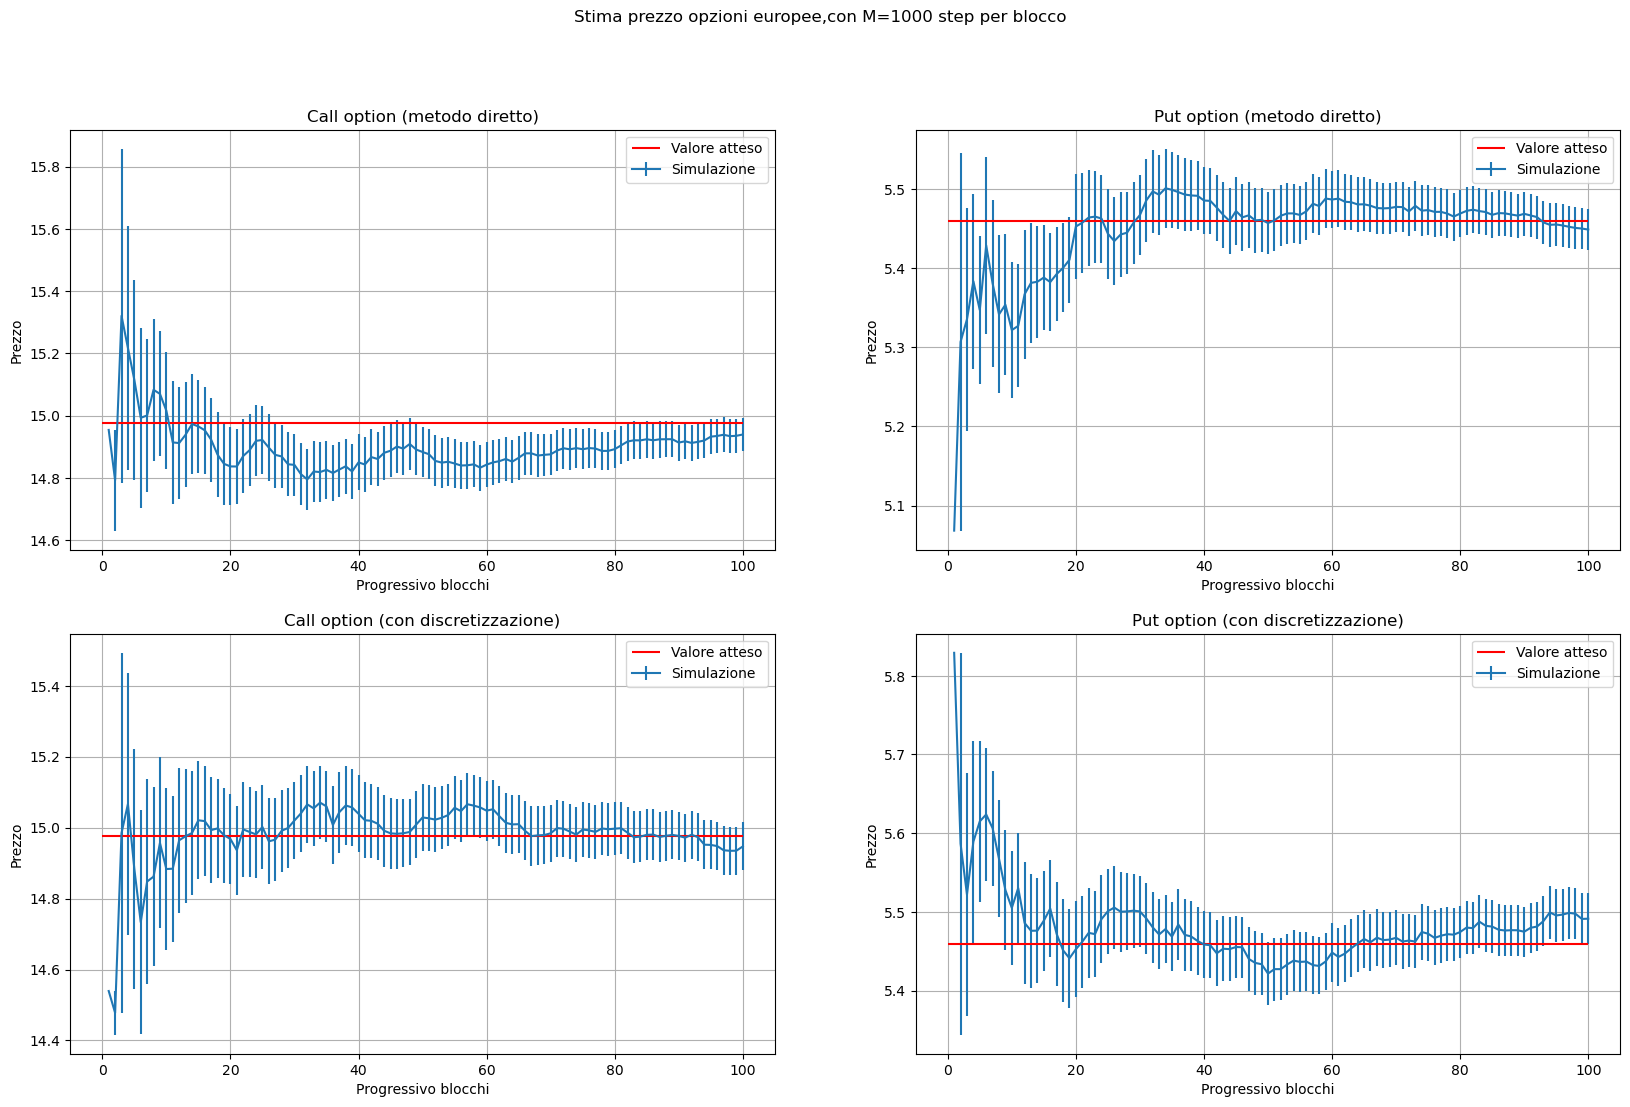

In [3]:


M=1000 #numero step per blocco
N=100 #numero blocchi

titles={0:"Call option (metodo diretto)", 1: "Put option (metodo diretto)", 2:"Call option (con discretizzazione)", 3: "Put option (con discretizzazione)"}
expected_value={0: call, 1:put}

prices=np.loadtxt("l_03_es_3/results.csv", usecols=(0,2,4,6), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo
errors=np.loadtxt("l_03_es_3/results.csv", usecols=(1,3,5,7), delimiter=',', unpack='true',skiprows=1) #carica i dati, saltando la riga del titolo

n=np.arange(1,N+1) #progressivo dei blocchi

fig,axs=plt.subplots(2,2,figsize=[20,12])


for i,ax in enumerate(axs.flatten()):
    ax.errorbar(n,prices[i][:],errors[i][:]) #traccia l'i-esimo grafico 
    ax.hlines(expected_value[i%2],0,N,color="red")#traccia una linea corrispondente al valore atteso
    ax.set_title(titles[i]) #
    ax.set_xlabel("Progressivo blocchi")
    ax.set_ylabel("Prezzo")
    ax.legend(["Valore atteso","Simulazione"],loc="best")
    ax.grid(True)

plt.suptitle(f"Stima prezzo opzioni europee,con M={M} step per blocco")
plt.show()

I valori trovati dalla simulazione si avvicinano a quelli attesi. Inoltre non ci sono visibili differenze tra i valori ottenuti trovando direttamente $S(T)$ rispetto a quelli ottenuti discretizzando nei $R$ sottointervalli (oltre che quelle dovute alla natura stocastica della simulazione). 